# Classifying Documents

# **Classifying Document**

Estimated time needed: **60** minutes

Imagine working at a prestigious newspaper or magazine company that boasts an extensive archive of documents dating back through the annals of time. Amid this treasure trove of information, a monumental task lies ahead: organizing these historical documents into their relevant topic sections. This strategic curation not only promises to enhance the user experience by delivering more streamlined content but also presents an opportunity to breathe new life into invaluable insights from the past through a modern lens. However, the sheer volume and scope of this undertaking call for a sophisticated solution. 

![Documents Overload](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-GPXX0Y15EN/docs.png)

The implementation of an automated machine learning system makes it very efficient. Such a system, equipped with advanced natural language processing and machine learning capabilities, could sift through the vast archives, categorizing articles into their respective topics with remarkable precision. As a result, readers would seamlessly access a wealth of knowledge tailored to their interests, while the editorial team gains newfound agility in content management.

In this project, you will embark on the exciting task of classifying news articles for a content search engine. The goal is to build a model that can automatically categorize news articles into different topics or classes, enabling the search engine to deliver relevant content to users efficiently. To achieve this, you will leverage the powerful torchtext library, which simplifies the process of creating a dataset for text classification analysis.

With torchtext, you'll have the flexibility to access and preprocess raw news data effortlessly. The library enables you to convert text strings into torch.Tensors, which are essential for training machine learning models. By using torchtext's convenient functionalities, you can set up an efficient data processing pipeline that prepares your text data for classification.

Throughout this tutorial, you'll demonstrate how to effectively shuffle and iterate through the processed data using torch.utils.data.DataLoader. This DataLoader simplifies the data handling process, allowing you to focus on building and training your text classification model effectively.


# Objectives

After completing this lab, you will be able to:

- Work with datasets and understand tokenizer, embedding bag technique and vocabulary.
- Explore embeddings in PyTorch and understand token indices.
- Perform text classification using data loader and apply it on a neural network model.
- Train the text classification model on a news dataset.
- Engage in various exercises to solidify your understanding.


## Import Libraries

In [194]:
import pandas as pd
import numpy as np
import torch
from torchtext.vocab import build_vocab_from_iterator
from torchtext.data.utils import get_tokenizer
from torch.utils.data import DataLoader

## Text classification
Let's build a text classification model using PyTorch and torchtext to classify news articles into one of the four categories: World, Sports, Business, and Sci/Tech.


### Import bank dataset

Load the AG_NEWS dataset for the train split and split it into input text and corresponding labels:


In [195]:
from torchtext.datasets import AG_NEWS

In [196]:
train_iter = iter(AG_NEWS(split="train")) # iterator object

The AG_NEWS dataset in torchtext does not support direct indexing like a list or tuple. It is not a random access dataset but rather an iterable dataset that needs to be used with an iterator. This approach is more effective for text data.


In [197]:
print(train_iter)

<generator object ShardingFilterIterDataPipe.__iter__ at 0x0000028979D10040>


In [198]:
(y,text) = train_iter.__next__()
# seems torch dataset has issues beacuse of poorly updation since 2023
# So we move to hugging face dataset  

AttributeError: 'NoneType' object has no attribute 'Lock'
This exception is thrown by __iter__ of _MemoryCellIterDataPipe(remember_elements=1000, source_datapipe=_ChildDataPipe)

In [199]:
from datasets import load_dataset

In [200]:
dataset = load_dataset("AG_NEWS")
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

In [201]:
train_iter = iter(dataset["train"])

In [202]:
sample = next(train_iter)
print("Label:",sample["label"])
print("Text:", sample["text"])

Label: 2
Text: Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.


Find the label of the sample.


In [203]:
ag_news_label = {1:"World", 2:"Sports", 3:"Business", 4:"Sci/Tec"}
ag_news_label[sample["label"]]


'Sports'

Also, use the dataset to find all the classes.


In [204]:
num_classes = len(set([item["label"] for item in train_iter]))
num_classes

4

### Tokenization

Create the tokens, also build the vocabulary as before, just using the AG dataset to obtain token indices


In [205]:
tokenizer = get_tokenizer("basic_english")
dataset = load_dataset("AG_NEWS")
# define function for tokenize the iteration
#Hugging face dataset iterator have dict type data 
def yield_token(dataset):
    for row in dataset:
        yield tokenizer(row["text"].lower())
        
# Build vocabulary
vocab = build_vocab_from_iterator(yield_token(dataset["train"]),specials= ["<unk>"])
vocab.set_default_index(vocab["<unk>"])

In [206]:
print("Vocab Size:",len(vocab))
print("sample tokens:", list(vocab.get_stoi().keys())[:10])

Vocab Size: 95811
sample tokens: ['television', 'misnomer', 'television-watching', 'new', 'costs', '7-week', 'dutch', '35-10', 'tarceva', 'confidence']


### Dataset

You can convert the dataset into map-style datasets and then perform a random split to create separate training and validation datasets. The training dataset will contain 95% of the samples, while the validation dataset will contain the remaining 5%. These datasets can be used for training and evaluating a machine learning model for text classification on the AG_NEWS dataset.


In [207]:
from torchtext.data.functional import to_map_style_dataset
from torch.utils.data import random_split,Dataset


In [208]:
dataset = load_dataset("ag_news")

# HuggingFace dataset is ALREADY map-style — no conversion needed
# Just wrap it in a PyTorch Dataset to return (label, text) tuples
class AGNewsDataset(Dataset):
    
    def __init__(self, hf_split):
        self.data = hf_split
    
    def __len__(self):
        return len(self.data) 
    
    def __getitem__(self, index):
        row = self.data[index]
        return row["label"], row["text"]
    
train_dataset = AGNewsDataset(dataset["train"])
test_dataset = AGNewsDataset(dataset["test"])

num_train = int(len(train_dataset) * 0.95)
num_valid = len(train_dataset) - num_train

split_train, split_valid = random_split(train_dataset, [num_train, num_valid])

print("Train size:", num_train)
print("Valid size:", num_valid)
print("Test size:", len(test_dataset))

Train size: 114000
Valid size: 6000
Test size: 7600


In [209]:
split_train[6]

(2,
 "Wal-Mart Sees Nov. U.S. Sales Up 0.7 Pct (Reuters) Reuters - Wal-Mart Stores Inc. , the\\world's largest retailer, said on Saturday it expects a 0.7\\percent increase in November sales at its U.S. stores open at\\least one year, down from a forecast of 2 percent to 4 percent\\a week ago.")

The code checks if a CUDA-compatible GPU is available in the system using PyTorch, a popular deep learning framework. If a GPU is available, it assigns the device variable to "cuda" (which stands for CUDA, the parallel computing platform and application programming interface model developed by NVIDIA). If a GPU is not available, it assigns the device variable to "cpu" (which means the code will run on the CPU instead).


In [210]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [211]:
device.type

'cpu'

## Data Loader

Prepare the text processing pipeline with the tokenizer and vocabulary. The text and label pipelines will be used to process the raw data strings from the dataset iterators. 

The function **```text_pipeline```** will tokenize the input text, and **```vocab```** will then be applied to get the token indices. 
The **```label_pipeline```** will ensure that the labels start at zero.


In [256]:
def text_pipeline(input_text):
    return vocab(tokenizer(input_text))

def label_pipeline(x):
    return int(x) 

In [257]:
print(torch.tensor(text_pipeline("Breaking news from Wall Street!")))


tensor([2151,  136,   29,  431,  374,  764])


In PyTorch, the **`collate_fn`** function is used in conjunction with data loaders to customize the way batches are created from individual samples. The provided code defines a `collate_batch` function in PyTorch, which is used with data loaders to customize batch creation from individual samples. It processes a batch of data, including labels and text sequences. It applies the `label_pipeline` and `text_pipeline` functions to preprocess the labels and texts, respectively. The processed data is then converted into PyTorch tensors and returned as a tuple containing the label tensor, text tensor, and offsets tensor representing the starting positions of each text sequence in the combined tensor. The function also ensures that the returned tensors are moved to the specified device (e.g., GPU) for efficient computation.


In [258]:
def collate_func(dataset):
    label_list, text_list, offsets = [],[],[0]
    for batch in dataset:
        label_list.append(label_pipeline(batch[0]))
        process_text = torch.tensor(text_pipeline(batch[1]), dtype=torch.int64)
        text_list.append(process_text)
        offsets.append(process_text.size(0))
        
    label_list = torch.tensor(label_list, dtype=torch.int64)
    offsets = torch.tensor(offsets[:-1]).cumsum(dim=0)
    text_list = torch.cat(text_list)
    
    return label_list.to(device), text_list.to(device), offsets.to(device)
        

Convert the dataset objects to a data loader by applying the collate function.


In [259]:
batch_size = 64

train_dataloader = DataLoader(
    split_train,
    batch_size = batch_size,
    shuffle=True,
    collate_fn=collate_func)

valid_dataloader = DataLoader(
    split_valid,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_func
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_func
)

You can observe the output sequence when you have the label, text, and offsets for each batch.


In [260]:
label, text, offset = next(iter(valid_dataloader))
label, text, offset

(tensor([0, 2, 3, 3, 0, 3, 2, 2, 0, 3, 3, 0, 3, 2, 0, 1, 1, 3, 0, 3, 3, 3, 2, 0,
         0, 1, 1, 1, 2, 0, 1, 1, 0, 3, 0, 0, 1, 2, 1, 3, 3, 0, 0, 0, 1, 2, 2, 1,
         0, 1, 1, 3, 3, 2, 1, 1, 3, 0, 1, 2, 1, 0, 1, 1]),
 tensor([  36,  447, 1254,  ..., 6511, 3908,    1]),
 tensor([   0,   54,  104,  127,  149,  216,  255,  305,  340,  383,  441,  493,
          530,  553,  584,  623,  669,  696,  743,  770,  838,  873,  934,  978,
         1024, 1081, 1126, 1176, 1215, 1239, 1268, 1304, 1352, 1394, 1430, 1475,
         1524, 1562, 1601, 1638, 1702, 1748, 1779, 1823, 1883, 1913, 1965, 2003,
         2049, 2142, 2177, 2213, 2242, 2285, 2325, 2369, 2413, 2450, 2500, 2550,
         2579, 2625, 2669, 2707]))

## Design the Neural Network Model

In [261]:
from torch import nn

In [262]:
class TextClssifierModel(nn.Module):
    
    def __init__(self, vocab_size, emded_dim, num_class):
        super(TextClssifierModel,self).__init__()
        self.emdedding = nn.EmbeddingBag(vocab_size, emded_dim, sparse=False)
        self.fc = nn.Linear(emded_dim, num_class)
        self.init_weight()
        
    def init_weight(self):
        initrange = 0.5
        self.emdedding.weight.data.uniform_(-initrange,initrange)
        self.fc.weight.data.uniform_(-initrange,initrange)
        self.fc.bias.data.zero_()
        
    def forward(self, text, offset):
        embedded = self.emdedding(text, offset)
        return self.fc(embedded)

One important thing — forward() returns raw logits (unnormalised scores), not probabilities. To get probabilities you apply softmax, but that's handled outside the model by the loss function (nn.CrossEntropyLoss does it internally).

Initializing parameters


In [263]:
embeded_dim = 64
vocab_size = len(vocab)
num_class = num_classes

### Build the Model

In [264]:
model = TextClssifierModel(vocab_size,embeded_dim,num_class)
model

TextClssifierModel(
  (emdedding): EmbeddingBag(95811, 64, mode='mean')
  (fc): Linear(in_features=64, out_features=4, bias=True)
)

The code line `predicted_label=model(text, offsets)` is used to obtain predicted labels from a machine learning model for a given input text and its corresponding offsets. The `model` is the machine learning model being used for text classification or similar tasks.


In [265]:
predicted_label = model(text,offset)

In [266]:
predicted_label.shape

torch.Size([64, 4])

Function **`predict`** takes in a text and a text pipeline, which preprocesses the text for machine learning. It uses a pre-trained model to predict the label of the text for text classification on the AG_NEWS dataset. The function returns the predicted label as a result.


In [267]:
def predict (text, text_pipeline):
    with torch.no_grad():
        tensor_text = torch.tensor(text_pipeline(text))
        predict_output = model(tensor_text, torch.tensor([0]))
        return ag_news_label[predict_output.argmax(1).item()+1]   

In [268]:
predict("I like cricket", text_pipeline)

'Sci/Tec'

### Define evaluation function

In [269]:
def evaluate(dataloader):
    model.eval()
    total_acc, total_counter =0,0
    
    with torch.no_grad():
        for idx, (label,text,offset) in enumerate (dataloader):
            predict_label = model(text,offset)
            total_acc += (predict_label.argmax(1) == label).sum().item()
            
            total_counter += label.size(0)
    return total_acc/total_counter  

In [270]:
# evaluate the valid dataloader
valid_eval = evaluate(valid_dataloader)
valid_eval

0.288

## Model Training



Set the learning rate (LR) to 0.1, which determines the step size at which the optimizer updates the model's parameters during training. The CrossEntropyLoss criterion is used to calculate the loss between the model's predicted outputs and the ground truth labels. This loss function is commonly employed for multi-class classification tasks.

The chosen optimizer is Stochastic Gradient Descent (SGD), which optimizes the model's parameters based on the computed gradients with respect to the loss function. The SGD optimizer uses the specified learning rate to control the size of the weight updates.

Additionally, a learning rate scheduler is defined using StepLR. This scheduler adjusts the learning rate during training, reducing it by a factor (gamma) of 0.1 after every epoch (step) to improve convergence and fine-tune the model's performance. These components together form the essential setup for training a neural network using the specified learning rate, loss criterion, optimizer, and learning rate scheduler.


In [271]:
lr = 0.1

# define loss function
criterion = torch.nn.CrossEntropyLoss()
# define optimzer
optimizer = torch.optim.SGD(model.parameters(),lr= lr)
#define scheduler to adjust the learning rate
scheduler = torch.optim.lr_scheduler.StepLR(optimizer,1.0,gamma=0.1)

Train the Model

In [272]:
from tqdm import tqdm

epochs = 10
cum_loss_list =[]
acc_epoc = []
acc_old = 0

# we use tqdm for to get a progress bar to visualize training process
for epoch in tqdm(range(1+ epochs+1)):
    model.train()
    cum_loss = 0
    
    for idx,(label,text,offset) in enumerate(train_dataloader):
        # PyTorch accumulates gradients by default
        #Must clear them before each batch or they pile up from previous batches
        optimizer.zero_grad()
        # predict the label
        predicted_label = model(text, offset)
        # get the loss
        loss = criterion(predicted_label,label)
        # to computes gradients for every parameter in the model we backpropagate the loss
        loss.backward() 
        # use clip for prevent the gradiend explording
        torch.nn.utils.clip_grad_norm_(model.parameters(),0.1)
        # Update weights
        optimizer.step()
        # update cum_loss
        cum_loss += loss.item()
    
    cum_loss_list.append(cum_loss)
    acc_val = evaluate(valid_dataloader)
    acc_epoc.append(acc_val)
    
    if acc_val>acc_old:
        acc_old = acc_val
        torch.save(model.state_dict(),'text_classifier.pth')
    

100%|██████████| 12/12 [08:54<00:00, 44.54s/it]


You can plot the cost and accuracy for each epoch. You'll see that with just ten epochs, you achieve an accuracy of over 80% on the validation data. You can increase the number of epochs to observe further results.


In [273]:
import matplotlib.pyplot as plt

In [274]:
def plot(loss,acc):
    fig, ax1 = plt.subplots()
    color = 'tab:red'
    
    ax1.plot(loss, color=color)
    ax1.set_xlabel('epochs',color=color)
    ax1.set_ylabel('Total loss', color=color)
    ax1.tick_params(axis='y', color=color)
    
    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.plot(acc, color=color)
    ax2.set_ylabel('accuracy', color=color)
    ax2.tick_params(axis='y', color=color)
    
    fig.tight_layout()
    
    plt.show()
    

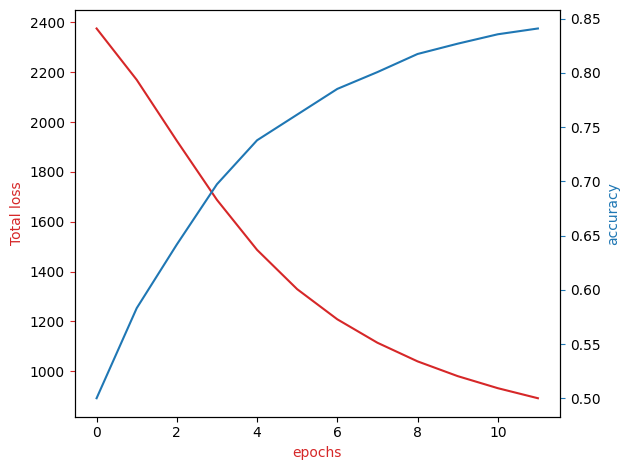

In [276]:
plot(cum_loss_list, acc_epoc)

You can evaluate the results on the test data and achieve over 80%.


In [280]:
test_eval = evaluate(test_dataloader)
print(f"Accuracy for test dataloader: {(100*test_eval):.2f}%")

Accuracy for test dataloader: 83.05%


In [281]:
article="""Canada navigated a stiff test against the Republic of Ireland on a rain soaked evening in Perth, coming from behind to claim a vital 2-1 victory at the Women’s World Cup.
Katie McCabe opened the scoring with an incredible Olimpico goal – scoring straight from a corner kick – as her corner flew straight over the despairing Canada goalkeeper Kailen Sheridan at Perth Rectangular Stadium in Australia.
Just when Ireland thought it had safely navigated itself to half time with a lead, Megan Connolly failed to get a clean connection on a clearance with the resulting contact squirming into her own net to level the score.
Minutes into the second half, Adriana Leon completed the turnaround for the Olympic champion, slotting home from the edge of the area to seal the three points."""

In [284]:
article_predict = predict(article,text_pipeline)
article_predict

'Sports'